In [1]:
!nvidia-smi
!pip install -q albumentations opencv-python-headless tqdm kaggle

Thu Oct  8 09:54:04 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   56C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

uploading a file through code

In [9]:
from google.colab import files
uploaded = files.upload()

Saving requirements.txt to requirements.txt
Saving README.md to README.md
Saving prepare_data.py to prepare_data.py
Saving train.py to train.py


checking the file is uploaded or not

In [8]:
!ls


data  sample_data  stage1_train.zip


kaggle api token : KGAT_4a296a75a91de4683895a60cb7ae0be4   

---
to download the dataset from kaggle by using its api token (data science bowl 2018)


In [6]:
import os, getpass
os.environ["KAGGLE_API_TOKEN"] = getpass.getpass("Paste Kaggle token: KGAT_4a296a75a91de4683895a60cb7ae0be4 ")

Paste Kaggle token: KGAT_4a296a75a91de4683895a60cb7ae0be4 ··········


download the api dataset as a zip folder

In [13]:
!mkdir -p data/raw/stage1_train
!unzip -q stage1_train.zip -d data/raw/stage1_train
!ls data/raw/stage1_train | head

replace data/raw/stage1_train/00071198d059ba7f5914a526d124d28e6d010c92466da21d4a04cd5413362552/images/00071198d059ba7f5914a526d124d28e6d010c92466da21d4a04cd5413362552.png? [y]es, [n]o, [A]ll, [N]one, [r]ename: 00071198d059ba7f5914a526d124d28e6d010c92466da21d4a04cd5413362552
003cee89357d9fe13516167fd67b609a164651b21934585648c740d2c3d86dc1
00ae65c1c6631ae6f2be1a449902976e6eb8483bf6b0740d00530220832c6d3e
0121d6759c5adb290c8e828fc882f37dfaf3663ec885c663859948c154a443ed
01d44a26f6680c42ba94c9bc6339228579a95d0e2695b149b7cc0c9592b21baf
0280fa8f60f6bcae0f97d93c28f60be194f9309ff610dc5845e60455b0f87c21
0287e7ee5b007c91ae2bd7628d09735e70496bc6127ecb7f3dd043e04ce37426
02903040e19ddf92f452907644ad3822918f54af41dd85e5a3fe3e1b6d6f9339
03398329ced0c23b9ac3fac84dd53a87d9ffe4d9d10f1b5fe8df8fac12380776
03b9306f44e9b8951461623dcbd615550cdcf36ea93b203f2c8fa58ed1dffcbe


Step 1: Check the structure and view samples

In [14]:
import os
print(os.listdir("/content/data/raw/stage1_train")[:5])

['237802ac5005f9cf782367156c46c383efd9e05088e5768ca883cbbe24abadb1', '21408476af0506331e8b5d49b385833e5ef1fbb90815fbf9af9d19b4bb145f76', 'aaa52100fafaa50877e777229cdf6cde7c422f145ff6719449b80631d9a3b0f6', '3f9fc8e63f87e8a56d3eaef7db26f1b6db874d19f12abd5a752821b78d47661e', '673baf65ae5c571d6be452eb41e79ef3fc2eb3fd238e621c6b7621763b429989']


670 samples


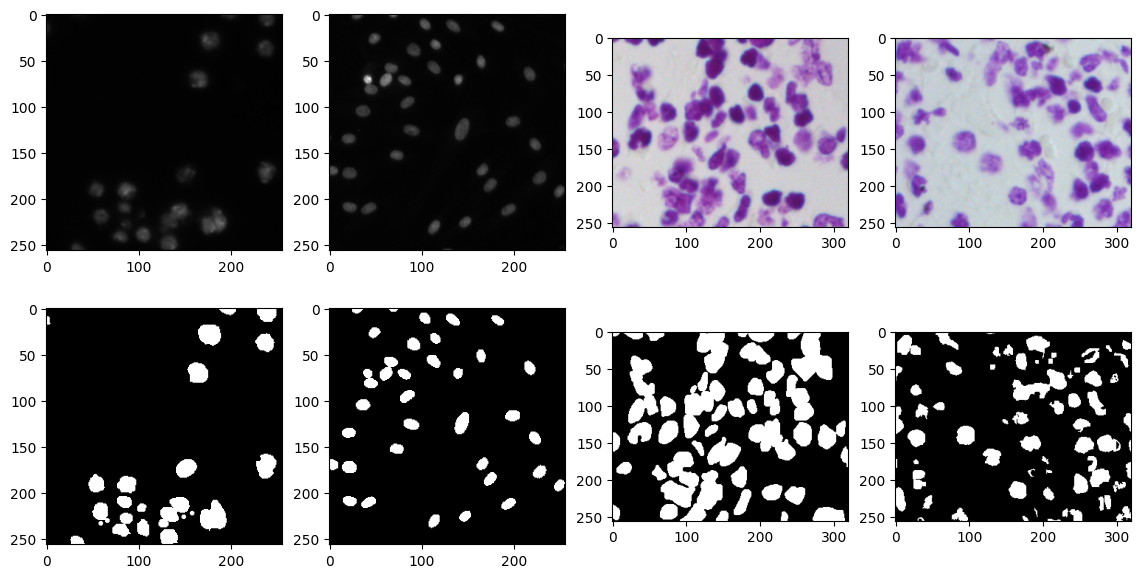

In [15]:
import os, glob, numpy as np
import matplotlib.pyplot as plt
from skimage.io import imread
from tqdm import tqdm

ROOT = "/content/data/raw/stage1_train"   # change to your path
ids = sorted(os.listdir(ROOT))
print(len(ids), "samples")

def load_sample(i):
    img = imread(f"{ROOT}/{i}/images/{i}.png")[..., :3]
    mask = np.zeros(img.shape[:2], np.uint8)
    for m in glob.glob(f"{ROOT}/{i}/masks/*.png"):
        mask = np.maximum(mask, (imread(m) > 0).astype(np.uint8))
    return img, mask

fig, ax = plt.subplots(2, 4, figsize=(14, 7))
for k in range(4):
    img, mask = load_sample(ids[k])
    ax[0, k].imshow(img); ax[1, k].imshow(mask, cmap="gray")
plt.show()

Step 2: Preprocess and split

In [16]:
import cv2, torch
from sklearn.model_selection import train_test_split

X, Y = [], []
for i in tqdm(ids):
    img, mask = load_sample(i)
    X.append(cv2.resize(img, (256, 256)))
    Y.append(cv2.resize(mask, (256, 256), interpolation=cv2.INTER_NEAREST))

X = np.array(X, np.float32) / 255.            # (670, 256, 256, 3)
Y = np.array(Y, np.float32)[:, None]          # (670, 1, 256, 256)
X = X.transpose(0, 3, 1, 2)                   # channels first

Xtr, Xva, Ytr, Yva = train_test_split(X, Y, test_size=0.15, random_state=42)
print(Xtr.shape, Xva.shape)

100%|██████████| 670/670 [00:48<00:00, 13.86it/s]


(569, 3, 256, 256) (101, 3, 256, 256)


Step 3: Model + training

In [10]:
!pip -q install segmentation-models-pytorch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 994.6 kB/s eta 0:00:00


In [17]:
import torch, numpy as np
import segmentation_models_pytorch as smp
from torch.utils.data import TensorDataset, DataLoader
from tqdm import tqdm

dev = "cuda"

# data loaders
tr = DataLoader(TensorDataset(torch.tensor(Xtr), torch.tensor(Ytr)), batch_size=16, shuffle=True)
va = DataLoader(TensorDataset(torch.tensor(Xva), torch.tensor(Yva)), batch_size=16)

# model, loss, optimizer, scheduler
model = smp.Unet("resnet34", encoder_weights="imagenet", in_channels=3, classes=1).to(dev)
dice = smp.losses.DiceLoss("binary")
bce = torch.nn.BCEWithLogitsLoss()
loss_fn = lambda p, y: dice(p, y) + bce(p, y)

opt = torch.optim.Adam(model.parameters(), lr=3e-4)
sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode="max", factor=0.5, patience=2)

EPOCHS, PATIENCE = 40, 6
best, wait = 0, 0

for ep in range(EPOCHS):
    # train
    model.train(); tl = 0
    for x, y in tqdm(tr, desc=f"Epoch {ep+1} train", leave=False):
        x, y = x.to(dev), y.to(dev)
        opt.zero_grad()
        loss = loss_fn(model(x), y)
        loss.backward()
        opt.step()
        tl += loss.item()

    # validate
    model.eval(); iou = 0
    with torch.no_grad():
        for x, y in tqdm(va, desc=f"Epoch {ep+1} val", leave=False):
            p = (torch.sigmoid(model(x.to(dev))) > 0.5).float().cpu()
            iou += ((p * y).sum() / ((p + y).clamp(0, 1).sum() + 1e-6)).item()
    val_iou = iou / len(va)

    sched.step(val_iou)

    # save best + early stopping
    if val_iou > best:
        best, wait = val_iou, 0
        torch.save(model.state_dict(), "best_model.pth")
    else:
        wait += 1

    print(f"Epoch {ep+1} | loss {tl/len(tr):.4f} | val IoU {val_iou:.4f} | best {best:.4f} | lr {opt.param_groups[0]['lr']:.1e}")

    if wait >= PATIENCE:
        print(f"Early stopping at epoch {ep+1}")
        break

config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 87.3MB            

model.safetensors: downloading bytes:           |  0.00B            

Epoch 1 | loss 1.1404 | val IoU 0.5160 | best 0.5160 | lr 3.0e-04


Epoch 2 | loss 0.7554 | val IoU 0.7431 | best 0.7431 | lr 3.0e-04


...

Epoch 34 | loss 0.1178 | val IoU 0.8561 | best 0.8584 | lr 7.5e-05


Epoch 35 | loss 0.1141 | val IoU 0.8557 | best 0.8584 | lr 3.7e-05


Epoch 36 | loss 0.1126 | val IoU 0.8552 | best 0.8584 | lr 3.7e-05


Epoch 37 | loss 0.1129 | val IoU 0.8554 | best 0.8584 | lr 3.7e-05


Epoch 38 | loss 0.1123 | val IoU 0.8538 | best 0.8584 | lr 1.9e-05
Early stopping at epoch 38


Next cell: load the best model and view predictions

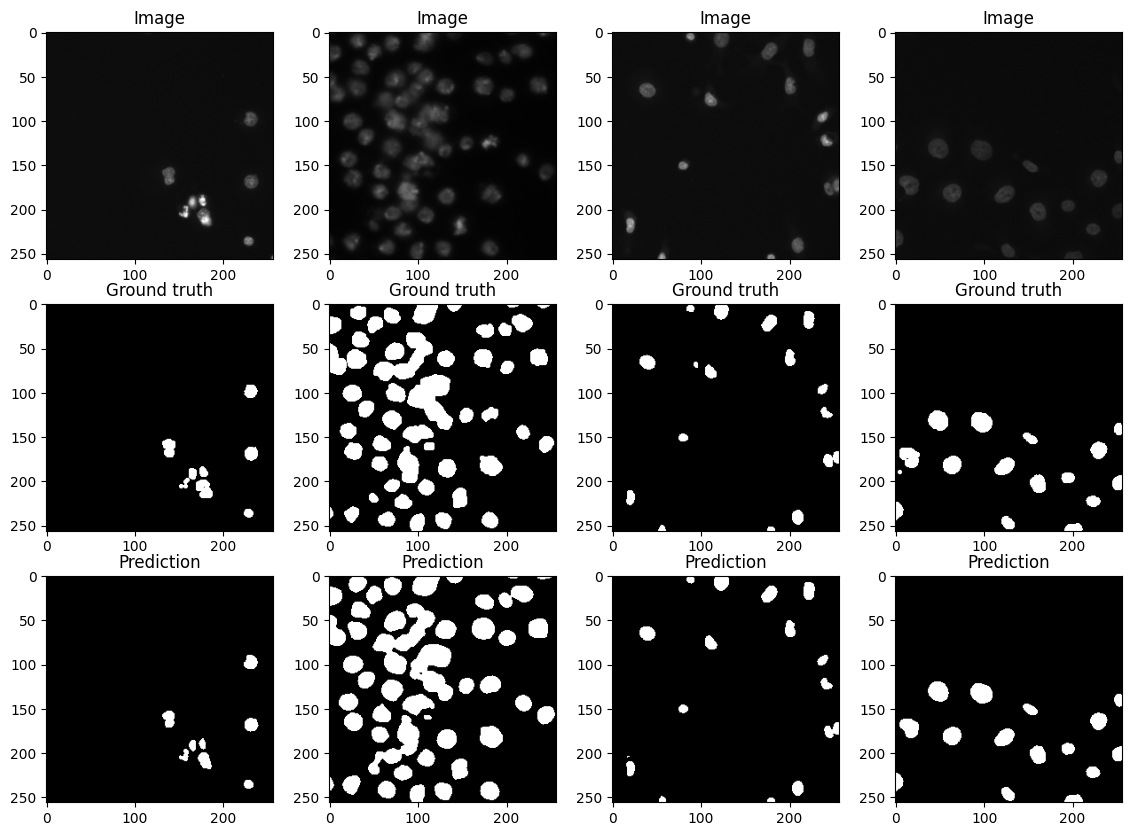

In [18]:
import matplotlib.pyplot as plt

model.load_state_dict(torch.load("best_model.pth"))
model.eval()

x = torch.tensor(Xva[:4]).to(dev)
with torch.no_grad():
    pred = (torch.sigmoid(model(x)) > 0.5).cpu().numpy()

fig, ax = plt.subplots(3, 4, figsize=(14, 10))
for k in range(4):
    ax[0, k].imshow(Xva[k].transpose(1, 2, 0));  ax[0, k].set_title("Image")
    ax[1, k].imshow(Yva[k, 0], cmap="gray");      ax[1, k].set_title("Ground truth")
    ax[2, k].imshow(pred[k, 0], cmap="gray");     ax[2, k].set_title("Prediction")
plt.show()

Next step: Watershed (split touching nuclei) why we are doing this is, the model predicited the nuclei correctly by som eof the nuclei is joined together for that case model cannot predict it by doing this watershed we can split the touching nuclei

100%|██████████| 4/4 [00:00<00:00, 101.07it/s]


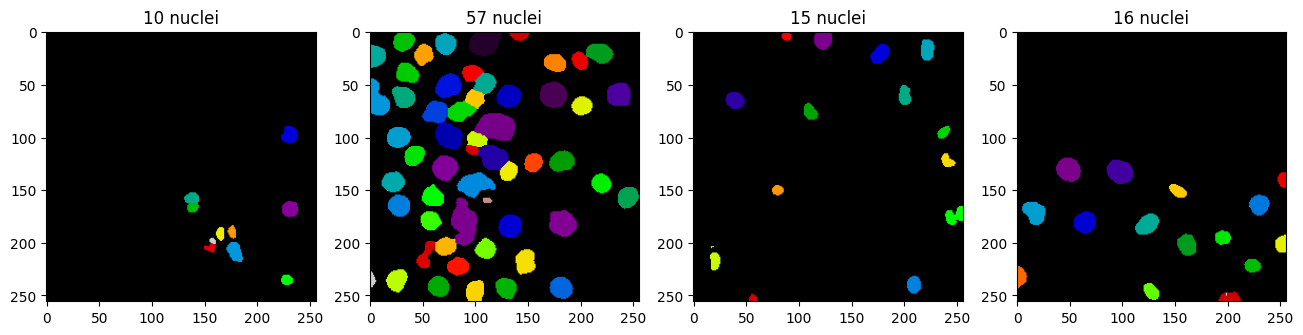

In [25]:
from scipy import ndimage as ndi
from skimage.segmentation import watershed
from skimage.feature import peak_local_max

def split_nuclei(mask, min_dist=7):
    dist = ndi.distance_transform_edt(mask)                  # center = high value
    peaks = peak_local_max(dist, min_distance=min_dist, labels=mask.astype(int))
    markers = np.zeros(mask.shape, dtype=int)
    markers[tuple(peaks.T)] = np.arange(1, len(peaks) + 1)   # 1 seed per nucleus
    return watershed(-dist, markers, mask=mask)

fig, ax = plt.subplots(1, 4, figsize=(16, 4))
for k in tqdm(range(4)):
    inst = split_nuclei(pred[k, 0].astype(bool), min_dist=5)   # try 5, 7, 10
    ax[k].imshow(inst, cmap="nipy_spectral")
    ax[k].set_title(f"{inst.max()} nuclei")
plt.show()

Better fix: smooth the distance map + remove tiny pieces

---
why this we are using is: min_dist 5 kudutha neraya seed podum, adhula chila seeds nucleus ku ullaye thappa vizhundhu, oru nucleus ah rendaa udaikkudhu. So count yerum, aana accuracy yeraadhu.


100%|██████████| 4/4 [00:00<00:00, 57.63it/s]


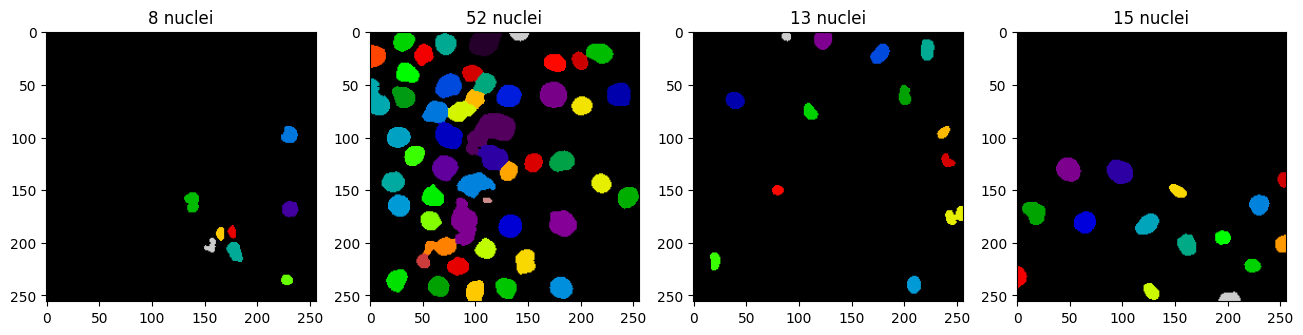

In [26]:
import matplotlib.pyplot as plt
from scipy import ndimage as ndi
from skimage.segmentation import watershed
from skimage.feature import peak_local_max
from skimage.filters import gaussian
from skimage.morphology import remove_small_objects
from tqdm import tqdm

def split_nuclei(mask, min_dist=7, min_size=20):
    dist = gaussian(ndi.distance_transform_edt(mask), sigma=1)   # smooth distance map
    peaks = peak_local_max(dist, min_distance=min_dist, labels=mask.astype(int))
    markers = np.zeros(mask.shape, dtype=int)
    markers[tuple(peaks.T)] = np.arange(1, len(peaks) + 1)
    inst = watershed(-dist, markers, mask=mask)
    return remove_small_objects(inst, min_size=min_size)         # drop tiny specks

fig, ax = plt.subplots(1, 4, figsize=(16, 4))
for k in tqdm(range(4)):
    inst = split_nuclei(pred[k, 0].astype(bool), min_dist=7, min_size=20)
    ax[k].imshow(inst, cmap="nipy_spectral")
    ax[k].set_title(f"{len(np.unique(inst)) - 1} nuclei")        # -1 for background
plt.show()

Step 1: Save your results from Colab

100%|██████████| 4/4 [00:00<00:00, 83.47it/s]


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

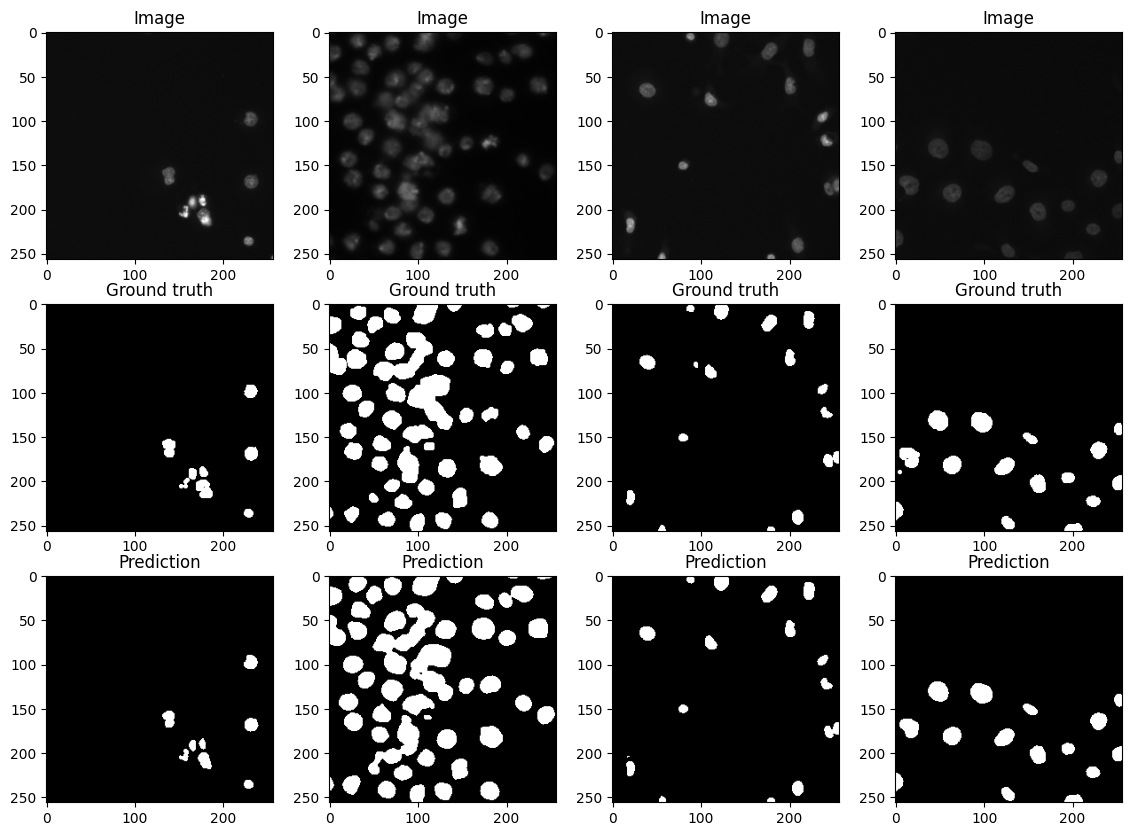

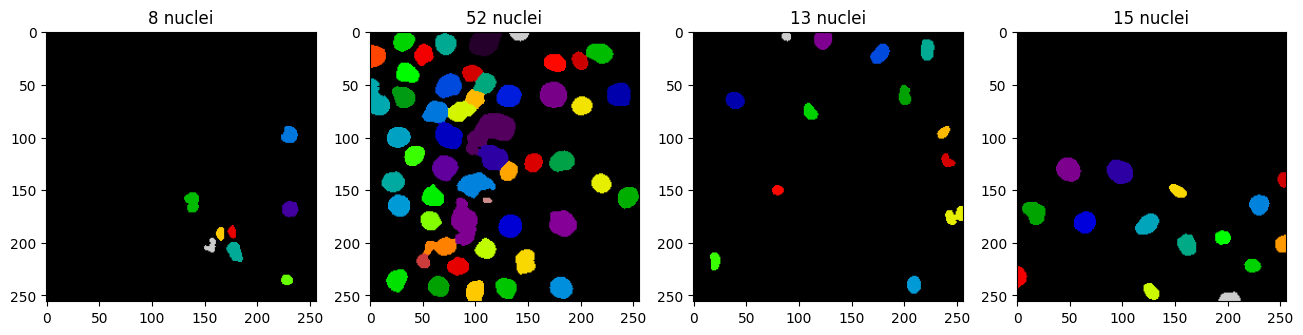

In [27]:
import os
os.makedirs("results", exist_ok=True)

# prediction figure
fig, ax = plt.subplots(3, 4, figsize=(14, 10))
for k in range(4):
    ax[0, k].imshow(Xva[k].transpose(1, 2, 0)); ax[0, k].set_title("Image")
    ax[1, k].imshow(Yva[k, 0], cmap="gray");     ax[1, k].set_title("Ground truth")
    ax[2, k].imshow(pred[k, 0], cmap="gray");    ax[2, k].set_title("Prediction")
plt.savefig("results/predictions.png", dpi=150, bbox_inches="tight")

# watershed figure
fig, ax = plt.subplots(1, 4, figsize=(16, 4))
for k in tqdm(range(4)):
    inst = split_nuclei(pred[k, 0].astype(bool))
    ax[k].imshow(inst, cmap="nipy_spectral")
    ax[k].set_title(f"{len(np.unique(inst)) - 1} nuclei")
plt.savefig("results/watershed.png", dpi=150, bbox_inches="tight")

from google.colab import files
files.download("results/predictions.png")
files.download("results/watershed.png")
files.download("best_model.pth")